In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [10]:
harmonics_params = [
    {'w': 0.6, 'b': 0.8},
    {'w': 0.3, 'b': 0.5},
    {'w': 0.7, 'b': 0.1},
    {'w': 0.2, 'b': 0.4},
    {'w': 0.9, 'b': 0.7}
]

N = 400
t = np.arange(1, N + 1)

In [11]:
def generate_signal(t, params, num_harmonics):
    signal = np.zeros_like(t, dtype=float)
    for i in range(num_harmonics):
        w = params[i]['w']
        b = params[i]['b']
        signal += np.sin(w * t + b)
    return signal

true_signals = {}
for i in range(1, 6):
    true_signals[f'signal_{i}'] = generate_signal(t, harmonics_params, i)

class KalmanFilter:
    def __init__(self, F, H, Q, R, P, x0):
        """
        F - матриця переходу стану
        H - матриця вимірювання
        Q - коваріація шуму процесу
        R - коваріація шуму вимірювання
        P - коваріація помилки оцінки (початкова)
        x0 - початковий стан
        """
        self.F = F
        self.H = H
        self.Q = Q
        self.R = R
        self.P = P
        self.x = x0

    def predict(self):
        self.x = self.F * self.x
        self.P = self.F * self.P * self.F + self.Q
        return self.x

    def update(self, z):
        K = self.P * self.H / (self.H * self.P * self.H + self.R)
        self.x = self.x + K * (z - self.H * self.x)
        self.P = (1 - K * self.H) * self.P

        return self.x

In [12]:
demo_signal_key = 'signal_3'
demo_noise_std = 2.5
demo_process_var = 0.01

s_true = true_signals[demo_signal_key]

# np.random.seed(42)
measurement_noise = np.random.normal(0, demo_noise_std, size=len(t))
z_measurements = s_true + measurement_noise

F = 1.0
H = 1.0
Q = demo_process_var
R = demo_noise_std ** 2
P = 1.0
x0 = 0.0

kf = KalmanFilter(F, H, Q, R, P, x0)
filtered_values = []

start_time = time.perf_counter()

for z in z_measurements:
    kf.predict()
    val = kf.update(z)
    filtered_values.append(val)

end_time = time.perf_counter()
exec_time = end_time - start_time

mse_noisy = np.mean((s_true - z_measurements) ** 2)
mse_filtered = np.mean((s_true - filtered_values) ** 2)

print(f"Результати для {demo_signal_key}")
print(f"Шум вимірювання (std): {demo_noise_std}")
print(f"Шум процесу (Q): {demo_process_var}")
print(f"MSE (Зашумлений vs Істинний): {mse_noisy:.4f}")
print(f"MSE (Фільтрований vs Істинний): {mse_filtered:.4f}")
print(f"Покращення точності: {mse_noisy / mse_filtered:.2f} разів")
print(f"Час виконання: {exec_time:.6f} с")

Результати для signal_3
Шум вимірювання (std): 2.5
Шум процесу (Q): 0.01
MSE (Зашумлений vs Істинний): 6.1943
MSE (Фільтрований vs Істинний): 1.6314
Покращення точності: 3.80 разів
Час виконання: 0.000338 с


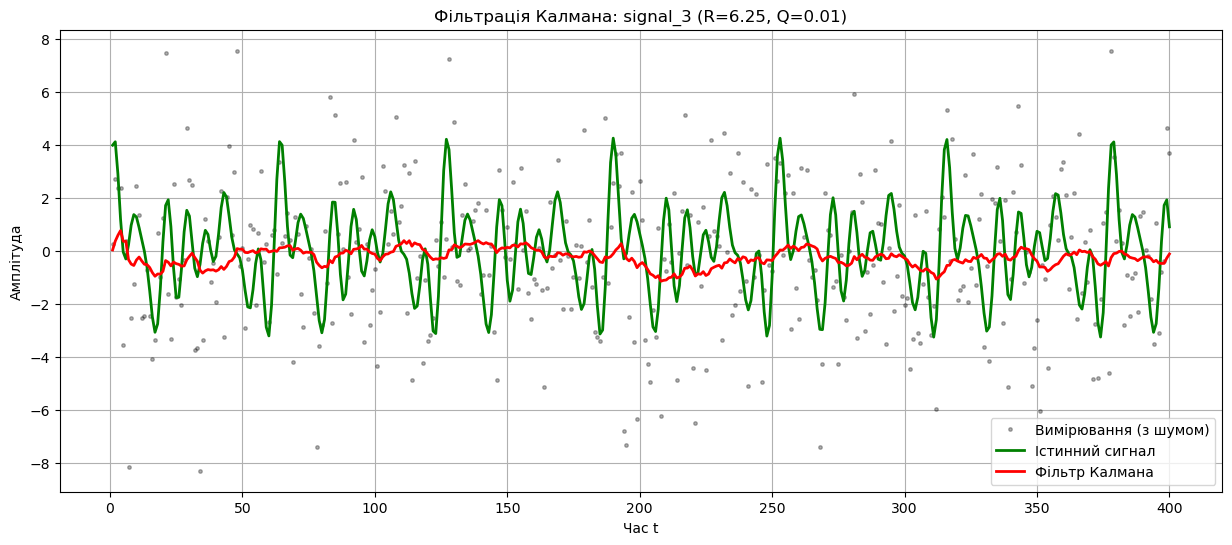

Сигнал     | Noise Std  | Proc Var   | MSE Noisy  | MSE Filter | Gain      
signal_1   | 1.5        | 0.001      | 2.2191     | 0.5054     | 4.39      
signal_1   | 3.5        | 0.1        | 12.8324    | 1.0966     | 11.70     
signal_5   | 1.5        | 0.001      | 2.5649     | 2.4575     | 1.04      
signal_5   | 3.5        | 0.01       | 13.5553    | 2.5081     | 5.40      


In [14]:
plt.figure(figsize=(15, 6))
plt.plot(t, z_measurements, 'k.', label='Вимірювання (з шумом)', alpha=0.3, markersize=5)
plt.plot(t, s_true, 'g-', linewidth=2, label='Істинний сигнал')
plt.plot(t, filtered_values, 'r-', linewidth=2, label='Фільтр Калмана')
plt.title(f'Фільтрація Калмана: {demo_signal_key} (R={R:.2f}, Q={Q})')
plt.xlabel('Час t')
plt.ylabel('Амплітуда')
plt.legend()
plt.grid(True)
plt.show()

print(f"{'Сигнал':<10} | {'Noise Std':<10} | {'Proc Var':<10} | {'MSE Noisy':<10} | {'MSE Filter':<10} | {'Gain':<10}")

test_cases = [
    ('signal_1', 1.5, 0.001),
    ('signal_1', 3.5, 0.1),
    ('signal_5', 1.5, 0.001),
    ('signal_5', 3.5, 0.01),
]

for sig_name, n_std, p_var in test_cases:
    s_true = true_signals[sig_name]
    noise = np.random.normal(0, n_std, size=len(t))
    z_meas = s_true + noise

    kf = KalmanFilter(F=1.0, H=1.0, Q=p_var, R=n_std**2, P=1.0, x0=0.0)
    s_filtered = []
    for z in z_meas:
        kf.predict()
        s_filtered.append(kf.update(z))

    mse_n = np.mean((s_true - z_meas) ** 2)
    mse_f = np.mean((s_true - s_filtered) ** 2)
    gain = mse_n / mse_f

    print(f"{sig_name:<10} | {n_std:<10} | {p_var:<10} | {mse_n:<10.4f} | {mse_f:<10.4f} | {gain:<10.2f}")